#Project Name: EDA
FedEx Logistics Performance Analysis

##Contribution - Individual

##Name: Khanderao patale


#Project summary

This project involves performing Exploratory Data Analysis (EDA) on a logistics dataset to understand the factors affecting delivery performance, customer satisfaction, and freight cost. The dataset includes shipment details such as shipment mode, vendor, country, delivery timelines, product information, and cost-related attributes.

The main focus of the analysis was to identify the causes of delivery delays and variations in shipping cost. To support this, several new features were created, including delay days, lead time, processing time, and on-time delivery indicators. These features helped in analyzing the complete shipment lifecycle from order placement to final delivery.

The analysis revealed that shipment mode has a strong impact on both delivery speed and cost, with faster modes being more reliable but expensive. Vendor performance also varied significantly, with some vendors contributing to higher delays. Additionally, regional differences were observed, where certain countries showed higher delays and data inconsistencies.

Outlier analysis was performed to detect extreme values in delay and cost, which helped identify unusual shipment cases and potential inefficiencies. Missing data was also analyzed instead of being ignored, revealing gaps in data recording and operational processes.

Various visualizations using Seaborn and Plotly were used to explore patterns, trends, and relationships between variables. Interactive charts allowed better understanding of how different factors influence delivery performance.

Overall, this project provides valuable insights into logistics operations and highlights areas for improvement, such as optimizing shipment modes, improving vendor efficiency, reducing processing time, and enhancing data quality to achieve better delivery performance and customer satisfaction.

#GitHub Link -

Link: https://github.com/Khanderao152/Exploratory-Data-Analysis-Project.git

#Problem Statement

In logistics operations, timely delivery and cost efficiency are critical for maintaining customer satisfaction. However, shipments often face delays, inconsistent delivery performance, and high freight costs due to various factors such as shipment mode, vendor performance, regional differences, and internal processing inefficiencies.

The objective of this project is to analyze a logistics dataset to identify the key factors affecting delivery delays and freight cost. Additionally, the project aims to detect operational inefficiencies, understand the impact of missing data, and evaluate vendor and region-wise performance.

By performing exploratory data analysis and creating meaningful features such as delay days, lead time, and processing time, the goal is to uncover patterns and insights that can help improve delivery performance, reduce cost, and enhance overall logistics efficiency.

In [147]:
# import library or require packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [148]:
#loading data
df=pd.read_csv("/content/drive/MyDrive/Amlabetter files/SCMS_Delivery_History_Dataset.CSV - SCMS_Delivery_History_Dataset.csv")


In [149]:
df.head() # first 5 row checking

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [150]:
df.tail() # last 5 row checking

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,10/16/14,N/A - From RDC,31-Jul-15,15-Jul-15,20-Jul-15,ARV,Pediatric,SCMS from RDC,"Lamivudine/Nevirapine/Zidovudine 30/50/60mg, d...",Lamivudine/Nevirapine/Zidovudine,Generic,30/50/60mg,Chewable/dispersible tablet - FDC,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,10/24/14,N/A - From RDC,31-Jul-15,6-Aug-15,7-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,8/12/14,N/A - From RDC,31-Aug-15,25-Aug-15,3-Sep-15,ARV,Adult,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Generic,600/300/300mg,Tablet - FDC,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,7/1/15,N/A - From RDC,9-Sep-15,4-Aug-15,11-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03
10323,86823,103-ZW-T30,FPQ-15197,SO-50022,DN-4336,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,10/16/14,N/A - From RDC,31-Aug-15,4-Aug-15,11-Aug-15,ARV,Pediatric,SCMS from RDC,"Lamivudine/Zidovudine 30/60mg, dispersible tab...",Lamivudine/Zidovudine,Generic,30/60mg,Chewable/dispersible tablet - FDC,60,36639,72911.61,1.99,0.03,"Cipla, Goa, India",No,Weight Captured Separately,Freight Included in Commodity Cost,85.82


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [152]:
# deleting unwanted column from dataset. which is not co-relation with my analysis
df.drop(columns=["Project Code","PQ #","PO / SO #","ASN/DN #"],inplace=True)

In [153]:
#checking null values each column in percentage
df.isnull().mean()*100

,0
ID,0.000000
Country,0.000000
Managed By,0.000000
Fulfill Via,0.000000
Vendor INCO Term,0.000000
Shipment Mode,3.487021
PQ First Sent to Client Date,0.000000
PO Sent to Vendor Date,0.000000
Scheduled Delivery Date,0.000000
Delivered to Client Date,0.000000


#Missing values

In [154]:
df["Shipment Mode"].isnull().sum() # checking how many missing no. it is imp for analys this column

np.int64(360)

In [155]:
df["Shipment Mode"].fillna("unknown" ,inplace=True)
#filling missing unknown becuase it should not affect my analysis if use mode result can change slightly since missing is 3.5%

/tmp/ipykernel_483/2368361011.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [156]:
df["Line Item Insurance (USD)"].isnull().sum()

np.int64(287)

In [157]:
df["Line Item Insurance (USD)"].fillna(df["Line Item Insurance (USD)"].median(),inplace=True)
#filling this with median this numeriac values and 2.78% missing

/tmp/ipykernel_483/886934193.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





#Duplicate checking

In [158]:
df.duplicated().sum()

np.int64(0)

In [159]:
df.drop_duplicates(inplace=True)

#Typecasting in require format

In [160]:
pd.set_option('display.max_columns', None)

In [161]:
date_cols = ['PQ First Sent to Client Date','PO Sent to Vendor Date',
             'Scheduled Delivery Date','Delivered to Client Date','Delivery Recorded Date']

df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce') # typecasting into date time

/tmp/ipykernel_483/954687634.py:4: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_483/954687634.py:4: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_483/954687634.py:4: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_483/954687634.py:4: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_483/954687634.py:4: UserWarning:

Could not infer format, so each element will be parsed individually

In [162]:
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce') #object to float typecasting


In [163]:
df['Weight (Kilograms)'] = df["Weight (Kilograms)"].apply(
    lambda x: x if str(x).isnumeric() else "NA"
) # text mining

In [164]:
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')

In [165]:
df.isnull().mean()*100

,0
ID,0.000000
Country,0.000000
Managed By,0.000000
Fulfill Via,0.000000
Vendor INCO Term,0.000000
Shipment Mode,0.000000
PQ First Sent to Client Date,25.968617
PO Sent to Vendor Date,55.521116
Scheduled Delivery Date,0.000000
Delivered to Client Date,0.000000


#Feature (Column) Engineering

In [166]:
df['Freight_Cost_Flag'] = df['Freight Cost (USD)'].isnull().map({True: 'Yes', False: 'No'})
# more than 30% data missing so i am creating new column as flag

In [167]:
df['Delay_Days'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days
#delay in days new column

In [168]:
df['On_Time'] = df['Delay_Days'].apply(lambda x: 'Yes' if x <= 0 else 'No')
#on time delivery for new column

In [169]:
df['Processing_Time'] = (df['PO Sent to Vendor Date'] - df['PQ First Sent to Client Date']).dt.days
#how much tume taken for processing order

In [170]:
df['Shipping_Time'] = (df['Delivered to Client Date'] - df['PO Sent to Vendor Date']).dt.days
#shipiing time for like reache to costomers

In [171]:
df['Lead_Time'] = (df['Delivered to Client Date'] - df['PQ First Sent to Client Date']).dt.days
#Lead Time = Total time taken from order start to final delivery

#Handling outlier

In [172]:
cols = ['Delay_Days', 'Lead_Time', 'Processing_Time', 'Freight Cost (USD)']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

Why this is used:
This approach is used to handle outliers across multiple columns efficiently without writing separate code for each column.

#Observation:
Extreme values were present in delay, lead time, and cost-related columns.

#Interpretation:
These values could distort analysis if not handled properly.

#Implication:
Capping outliers ensures more reliable and stable analysis results.

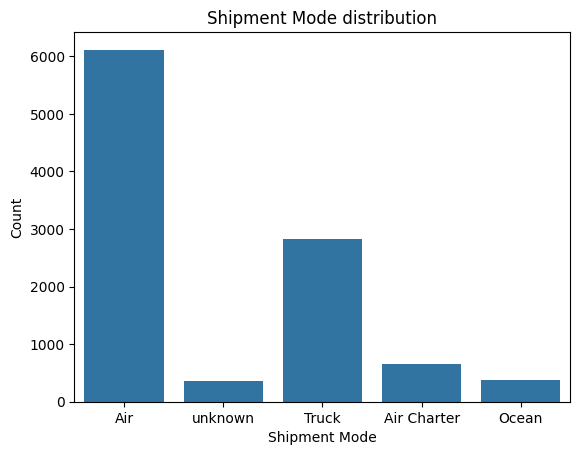

In [173]:
sns.countplot(x="Shipment Mode",data=df)
plt.title("Shipment Mode distribution")
plt.xlabel("Shipment Mode")
plt.ylabel("Count")
plt.show()

Why: To understand distribution of shipment modes.
#Observation:
One or two modes have higher counts.
#Interpretation:
Company relies more on certain transport methods.
#Implication:
Need to balance usage to reduce dependency risk.

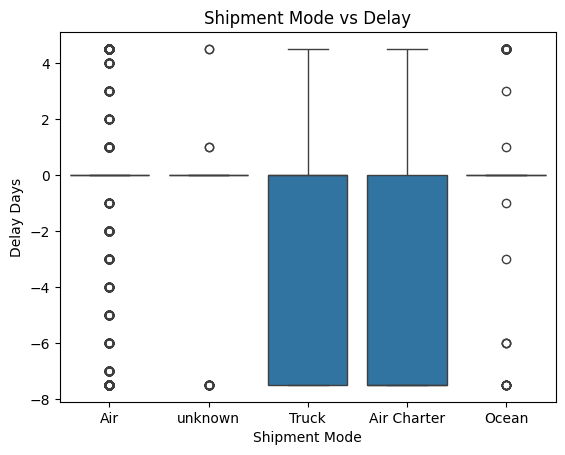

In [174]:
sns.boxplot(x='Shipment Mode', y='Delay_Days', data=df)
plt.title('Shipment Mode vs Delay')
plt.xlabel('Shipment Mode')
plt.ylabel('Delay Days')
plt.show()

Why: To compare delay distribution across modes.
#Observation:
Some modes have higher median delay.
#Interpretation:
Not all transport modes are equally efficient.
#Implication:
Prefer faster modes for critical deliveries.

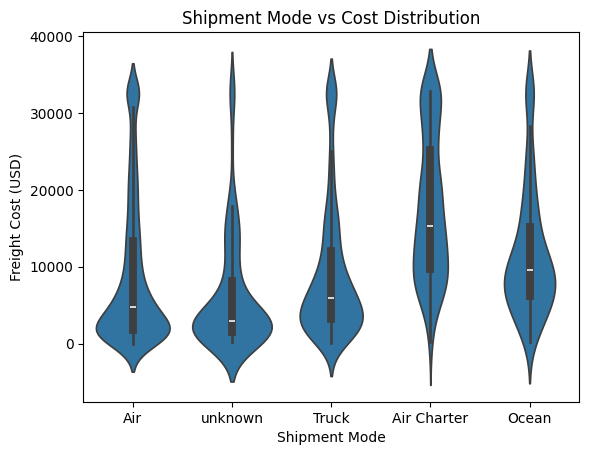

In [175]:
sns.violinplot(x='Shipment Mode', y='Freight Cost (USD)', data=df)
plt.title('Shipment Mode vs Cost Distribution')
plt.show()

Why: To see detailed cost distribution.
#Observation:
Air shows wider and higher cost spread.
#Interpretation:
High variability in cost for faster modes.
#Implication:
Control cost fluctuations in expensive modes.

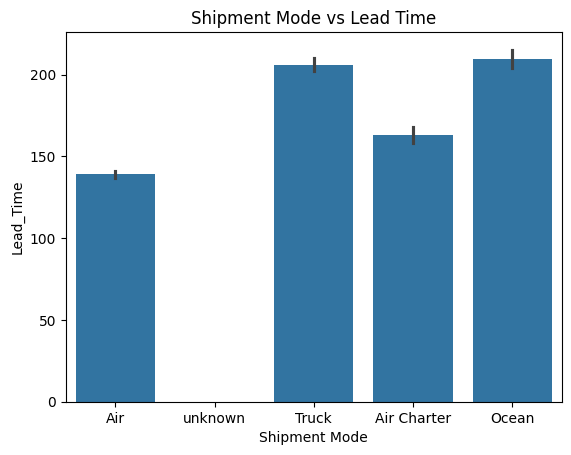

In [176]:
sns.barplot(x='Shipment Mode', y='Lead_Time', data=df)
plt.title('Shipment Mode vs Lead Time')
plt.show()

Why: To compare average delivery duration.
#Observation:
Some modes take longer overall.
#Interpretation:
Inefficient coordination in those modes.
#Implication:
Improve planning for slow modes.

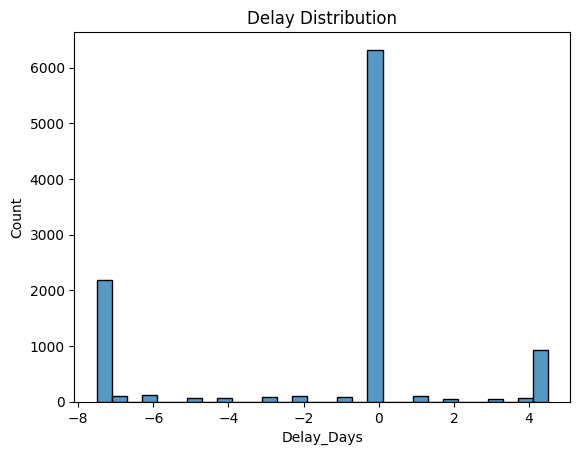

In [177]:
sns.histplot(df['Delay_Days'], bins=30)
plt.title('Delay Distribution')
plt.show()

Why: To understand spread of delays.
#Observation:
Most values near zero but some extreme delays.
#Interpretation:
System mostly stable but has outliers.
#Implication:
Focus on reducing extreme delays.

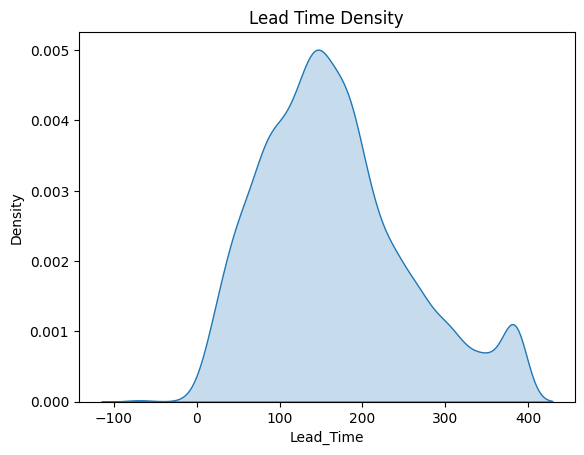

In [178]:
sns.kdeplot(df['Lead_Time'], fill=True)
plt.title('Lead Time Density')
plt.show()

Why: To visualize density of lead time.
#Observation:
Wide spread of values.
#nterpretation:
Inconsistent delivery timelines.
#Implication:
Standardize process flow.

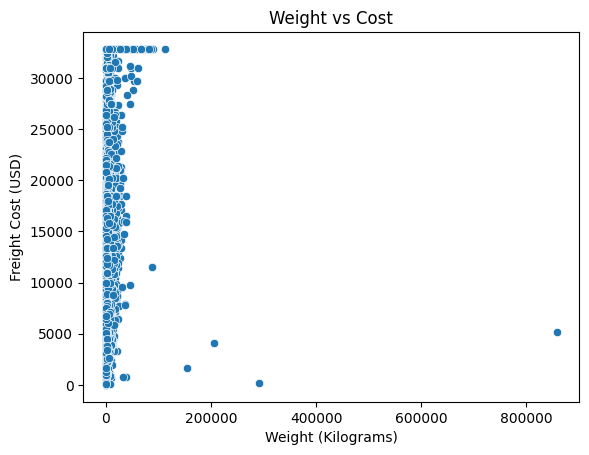

In [179]:
sns.scatterplot(x='Weight (Kilograms)', y='Freight Cost (USD)', data=df)
plt.title('Weight vs Cost')
plt.show()

Why: To check relationship between weight and cost.
#Observation:
Cost increases with weight.
#Interpretation:
Pricing model is logical.
#Implication:
Optimize packaging to reduce cost

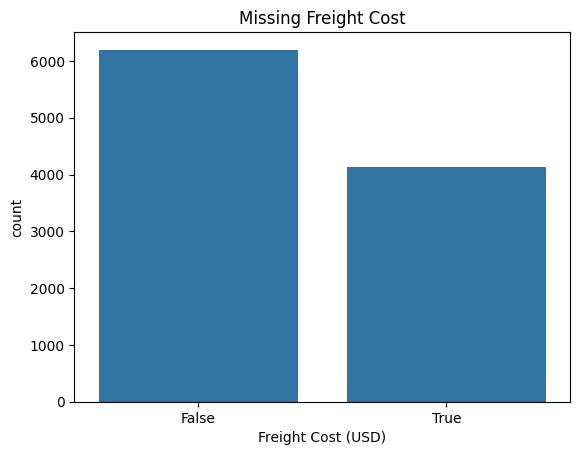

In [180]:
sns.countplot(x=df['Freight Cost (USD)'].isnull())
plt.title('Missing Freight Cost')
plt.show()

Why: To analyze missing data.
#Observation:
Significant missing values exist.
#Interpretation:
Data recording issue.
#Implication:
Improve data tracking system.

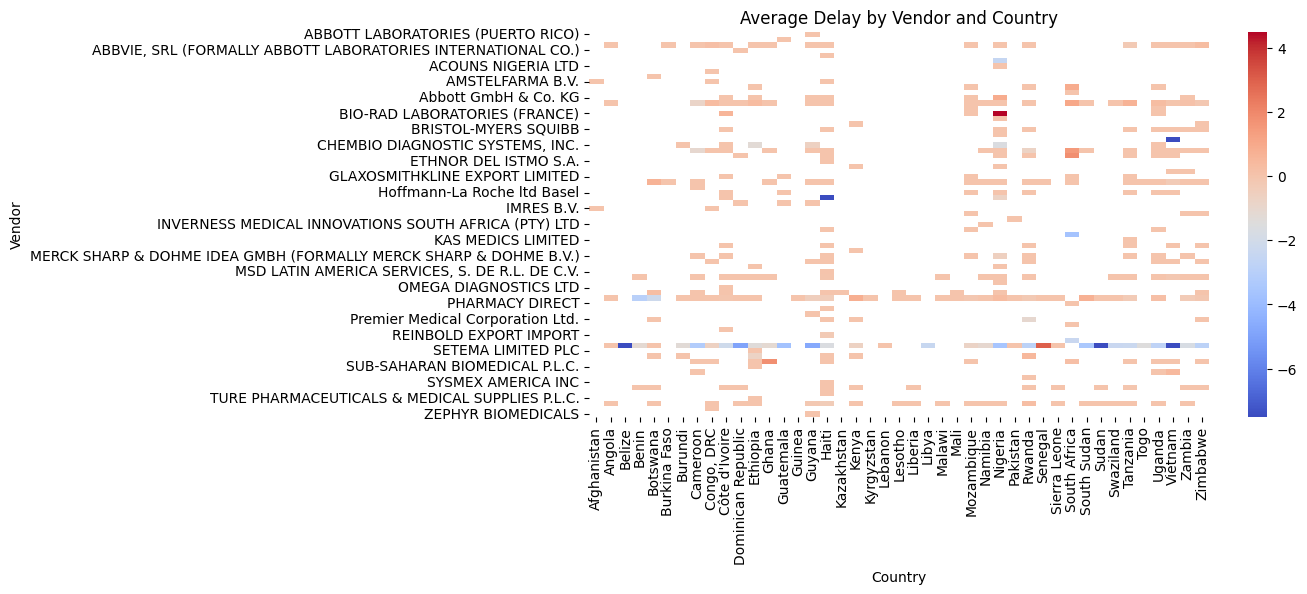

In [181]:
pivot_df = df.groupby(['Vendor', 'Country'])['Delay_Days'].mean().unstack()

plt.figure(figsize=(10,5))
sns.heatmap(pivot_df, cmap='coolwarm', annot=False)

plt.title('Average Delay by Vendor and Country')
plt.xlabel('Country')
plt.ylabel('Vendor')

plt.show()

Why this chart is used:
I used a heatmap to clearly compare delay across vendors and countries. It gives a structured and easy-to-read view instead of scattered points.

#Observation:
Some vendor-country combinations show higher delay values (darker colors), while others perform better.

#Interpretation:
Vendor performance varies significantly across regions, indicating inconsistency.

#Implication:
The company should focus on improving performance in high-delay vendor-country combinations.

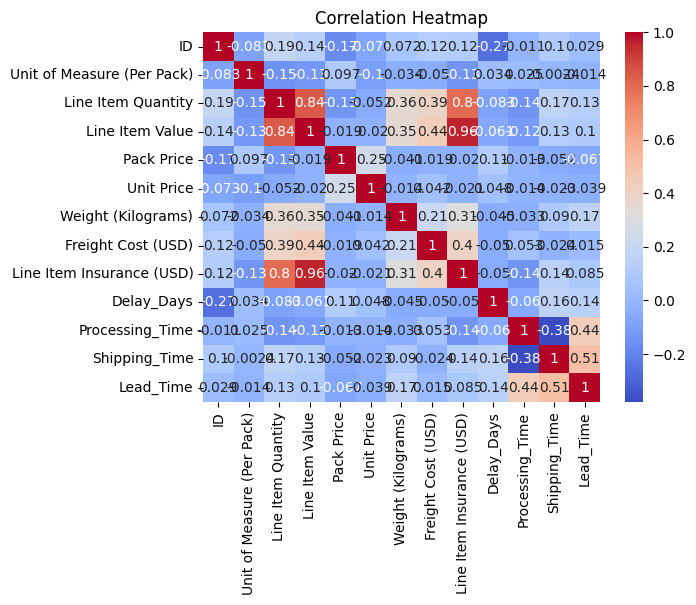

In [182]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Why: To find relationships between variables.
#Observation:
Lead time correlates with delay.
#Interpretation:
Longer processes increase delay.
#Implication:
Reduce lead time to improve performance.

In [183]:
px.box(df, x='Shipment Mode', y='Freight Cost (USD)', title='Cost by Shipment Mode')

Why: Interactive comparison of cost.
#Observation:
Air has higher cost range.
#Interpretation:
Faster delivery costs more.
#Implication:
Use selectively.

In [184]:
px.bar(df['Country'].value_counts(), title='Country Distribution')

Why: To visualize regional volume.
#Observation:
Few countries dominate.
#Interpretation:
Business concentration.
#Implication:
Focus improvement in key regions.

In [185]:
px.pie(df, names='Shipment Mode', title='Shipment Mode Share')

Why: To show proportion.
#Observation:
One mode dominates share.
#Interpretation:
Uneven distribution.
#Implication:
Diversify operations.

In [186]:
px.histogram(df, x='Freight Cost (USD)', title='Cost Distribution')

Why: To analyze cost spread.
#Observation:
Few high-cost outliers.
#Interpretation:
Inefficient shipments.
#Implication:
Investigate costly cases.

In [187]:
px.scatter(df, x='Lead_Time', y='Delay_Days', title='Lead Time vs Delay')

Why: To analyze relationship.
#Observation:
Positive trend.
#Interpretation:
Longer time leads to delay.
#Implication:
Reduce process time.

In [188]:
df['Month'] = df['Delivered to Client Date'].dt.month
px.line(df.groupby('Month').size(), title='Monthly Trend')

hy: To see time trends.
#Observation:
Some months peak.
#Interpretation:
Seasonal demand.
#Implication:
Plan resources accordingly.

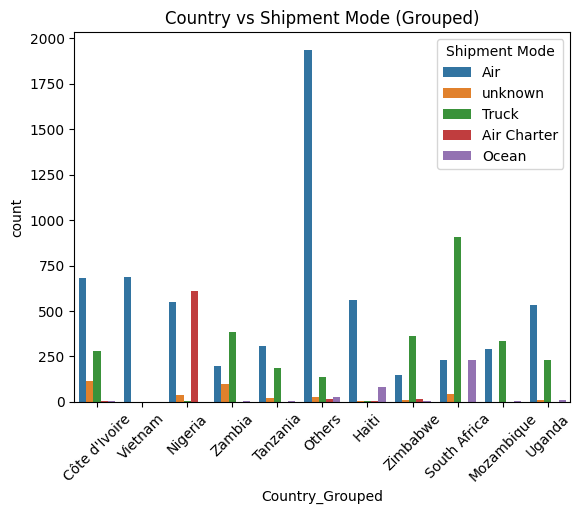

In [189]:
top_countries = df['Country'].value_counts().head(10).index

df['Country_Grouped'] = df['Country'].apply(
    lambda x: x if x in top_countries else 'Others'
)

sns.countplot(x='Country_Grouped', hue='Shipment Mode', data=df)
plt.xticks(rotation=45)
plt.title('Country vs Shipment Mode (Grouped)')
plt.show()

Why this chart is used:
Since there were too many countries, I grouped less frequent ones into "Others" to make the chart more readable.

#Observation:
Top countries clearly show shipment patterns, while smaller countries are combined.

#Interpretation:
Most business comes from a few key countries, while others contribute less.

#Implication:
The company should focus on major countries while maintaining basic support for smaller ones.




In [190]:
px.scatter_matrix(df, dimensions=['Lead_Time','Delay_Days','Freight Cost (USD)'])

Why: To compare multiple relationships.
#Observation:
Strong patterns between variables.
#Interpretation:
Variables are interrelated.
#Implication:
Optimize multiple factors together.

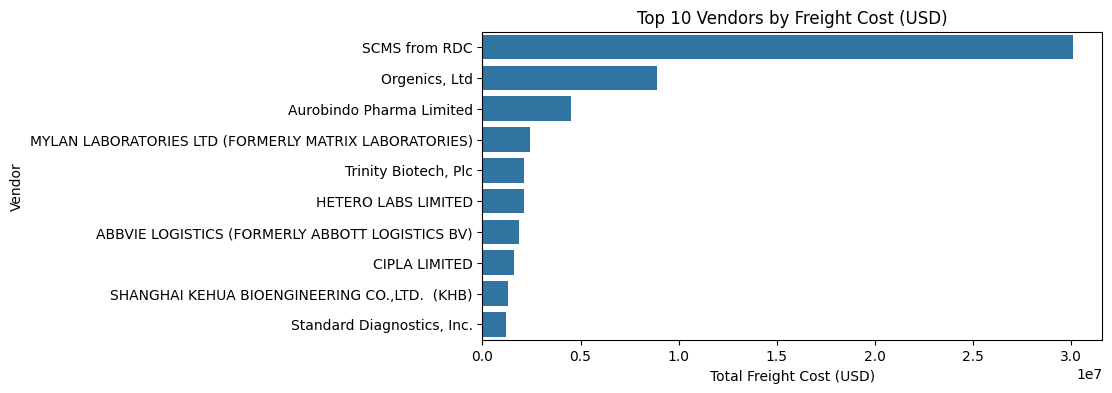

In [191]:
top_vendors = df.groupby('Vendor')['Freight Cost (USD)'].sum().nlargest(10).reset_index()


plt.figure(figsize=(8,4))

sns.barplot(x='Freight Cost (USD)', y='Vendor', data=top_vendors)

plt.title('Top 10 Vendors by Freight Cost (USD)')
plt.xlabel('Total Freight Cost (USD)')
plt.ylabel('Vendor')

plt.show()

Why this chart is used:

I used a bar chart to compare the top vendors based on total freight cost, as it clearly shows differences between them.

#Observation:

A few vendors contribute a large portion of total freight cost, while others have relatively lower values.

#Interpretation:

This indicates that the company relies heavily on certain vendors for high-value shipments.

#Implication:

The company should monitor these vendors closely, as they have a major impact on overall cost and performance.

In [192]:

# Dropdown columns
options = ['Shipment Mode', 'Country', 'Vendor']

fig = px.histogram(df, x='Shipment Mode', title='Interactive Distribution')

# Create buttons
buttons = []

for col in options:
    buttons.append(dict(
        label=col,
        method='update',
        args=[{'x': [df[col]]},
              {'title': f'Distribution of {col}'}]
    ))

# Add dropdown
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.2,
        y=1
    )]
)

fig.show()

Why this type of chart is used:

Instead of static charts, interactive charts allow filtering and exploration by clicking on values.

#Observation:

User can dynamically explore different categories like shipment mode, vendor, and country.

#Interpretation:

Interactive charts make it easier to identify patterns and relationships without creating multiple separate plots.

#Implication:

This approach improves analysis efficiency and helps in better decision-making.

In [193]:

px.box(df,
       x='Managed By',
       y='Delay_Days',
       color='On_Time',
       title='Delay Distribution by Managed By',
       labels={'Delay_Days':'Delay Days', 'Managed By':'Manager'})

Why this chart is used:
I used this chart to understand how delivery performance varies based on who manages the shipment.

#Observation:
Some managers show higher delay values and more variation compared to others.

#Interpretation:
This indicates that performance differs between managers, possibly due to differences in planning or coordination.

#Implication:
The company should identify best-performing managers and apply their practices to improve overall efficiency.

In [194]:
px.box(df,
       x='Product Group',
       y='Freight Cost (USD)',
       color='Shipment Mode',
       title='Product Group vs Freight Cost',
       labels={'Freight Cost (USD)':'Freight Cost'})

Why this chart is used:
I used this chart to analyze how freight cost varies across different product groups.

#Observation:
Some product groups have significantly higher cost distribution.

#Interpretation:
This may be due to weight, handling requirements, or shipment complexity.

#Implication:
The company can optimize packaging or logistics for high-cost product groups to reduce expenses.

#Final Conclusion

From the overall analysis, it is clear that delivery performance and freight cost are influenced by multiple factors such as shipment mode, vendor efficiency, country, and internal processing time. While most shipments are delivered on time, there are noticeable delays in specific cases due to operational inefficiencies. Cost variation is also significant and depends on shipment mode, weight, and product type. Additionally, missing data in important fields indicates gaps in data recording and process tracking.


##Key Findings

1. Shipment Mode Impact
Some shipment modes show higher delays and lead time.
 Faster modes (like air) are more reliable but expensive.
2. Vendor Performance
Certain vendors consistently show higher delays.
Vendor performance is not uniform across all regions.
3. Country-Level Differences
Some countries have higher delivery delays and missing data.
Business is concentrated in a few key regions.
4. Cost Behavior
Freight cost increases with weight and varies by shipment mode.
Some product groups and vendors contribute to higher costs.
5. Lead Time & Delay Relationship
Longer lead time directly increases chances of delay.
Processing and shipping time both affect delivery performance.
6. Missing Data Issues
High missing values in freight cost and PO dates.
Missing data is not random and is linked to specific vendors and Regions
7. Manager & Fulfillment Impact
Performance varies across managers and fulfillment methods.
Some fulfillment channels are slower than others.

##Insights (Business Understanding)

Delivery delay is not caused by one factor but a combination of shipment mode, vendor, and process inefficiencies.

High-cost shipments are mainly driven by mode selection and product characteristics.

Missing data itself reveals operational gaps, especially in cost tracking and vendor processes.

Vendor and regional performance should be monitored separately rather than globally.

Improving internal processing time can significantly reduce overall delays.

##Recommendations

Optimize shipment mode selection based on urgency and cost.
Monitor and improve underperforming vendors.
Focus on high-delay countries and improve logistics there.
Reduce lead time by improving internal processes.
Improve data collection systems to reduce missing values.
Use top-performing managers and methods as benchmarks.